# Week 9 - Multivariate Analysis, part 2

# 1. Lesson - no lesson this week

# 2. Weekly graph question

The graph below plots the first two principal component scores in a scatter plot.  What can be said about the three outliers in the upper left corner of the graph?  Is their first principal component score high or low?  What about their second principal component score?  What does that mean about their values in series_1, series_2, and series_3?  It seems to me that you can say something about series_3 (what can you say?) but you may have a harder time saying something about series_1 and series_2, and an almost impossible time saying anything about the relative values of series_1 and series_2.  Why is that?  How are series_1 and series_2 related, according to how they were created?  If you like, try drawing a pairplot for all three series and see what you get.

Overall, what are the advantages and disadvantages of the graph below?  Does it show anything interesting?

In [15]:
print("""The outliers that are on the far left on the x-axis and are far up on the y-axis. 
The first PCS is low; they are far to the left of the scatterplot. 
The second PCS is high; they’re far upward on the y-axis. 
Low First PCS means a low weighted sum of ser1, ser2, and ser3. 
All three (especially ser3, which has high variance) are probably low. 
High Second PCS means the second component looks like a contrast between ser1 and ser2: +ser1 - ser2; 
so ser1 is high and ser2 is low.

For the outliers, ser3 is low—a strong effect from PC1 being low; 
ser1 > ser2—a strong effect from PC2 being high. 
But ser1 and ser2 values alone can't be precisely known, only their contrast.

You can say something about series_3, but not precisely about series_1 and series_2 because 
PC1 loads strongly on ser3, and since PC1 is low, we infer ser3 is low. 
PC2 tells us the difference between ser1 and ser2, not their absolute values. 
You know ser1 > ser2, but not their actual magnitudes.

Also, ser1 and ser2 are highly correlated by construction, so they tend to move together; 
their relative difference isn't large enough for PC2 to explain a lot of variance. 
This makes series_2 almost a scaled version of series_1, with small multiplicative noise. 
They are highly correlated; any difference is small and random. 

This correlation explains why the first principal component (PC1) largely reflects shared variance among all series. 

Overall, the advantages of this graph are that it captures structure and outliers in the data and 
shows how points cluster in reduced-dimensional space. 
But a disadvantage is that it is hard to interpret exact variable values from the PC scores.
""")

The outliers that are on the far left on the x-axis and are far up on the y-axis. 
The first PCS is low; they are far to the left of the scatterplot. 
The second PCS is high; they’re far upward on the y-axis. 
Low First PCS means a low weighted sum of ser1, ser2, and ser3. 
All three (especially ser3, which has high variance) are probably low. 
High Second PCS means the second component looks like a contrast between ser1 and ser2: +ser1 - ser2; 
so ser1 is high and ser2 is low.

For the outliers, ser3 is low—a strong effect from PC1 being low; 
ser1 > ser2—a strong effect from PC2 being high. 
But ser1 and ser2 values alone can't be precisely known, only their contrast.

You can say something about series_3, but not precisely about series_1 and series_2 because 
PC1 loads strongly on ser3, and since PC1 is low, we infer ser3 is low. 
PC2 tells us the difference between ser1 and ser2, not their absolute values. 
You know ser1 > ser2, but not their actual magnitudes.

Also, ser1 and ser2

[0.79916477 0.18990532 0.01092991]
[[ 0.26541493  0.30096233  0.91595665]
 [ 0.60337553  0.6891417  -0.40127506]
 [ 0.75199261 -0.65917023 -0.00131519]]


Text(0, 0.5, 'Second Principal Component Score')

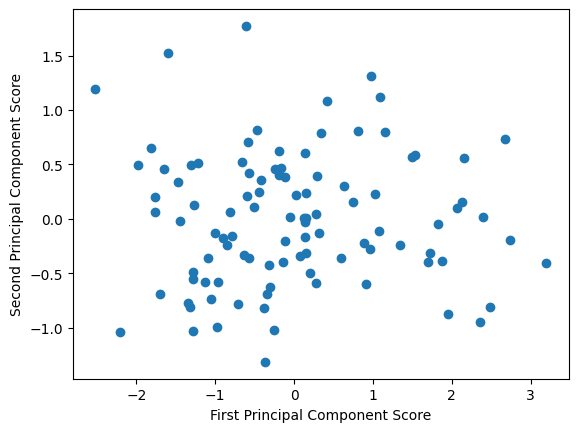

In [16]:
import numpy as np
import pandas as pd
from sklearn import decomposition
import matplotlib.pyplot as plt

np.random.seed(0)
num_points = 100
series_1 = np.random.normal(loc = 2, scale = 0.5, size = num_points)
series_2 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.1, size = num_points))
series_3 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.5, size = num_points))
df = pd.DataFrame({'ser1': series_1, 'ser2': series_2, 'ser3': series_3})
df = df - df.mean() # set mean to zero, so we don't have to subtract mean from the principal component scores

pca3 = decomposition.PCA(n_components = 3)
pca3.fit(df)
print(pca3.explained_variance_ratio_)
print(pca3.components_)

first_principal_component_score = df.dot(pca3.components_[0])
second_principal_component_score = df.dot(pca3.components_[1])
plt.scatter(first_principal_component_score, second_principal_component_score)
plt.xlabel("First Principal Component Score")
plt.ylabel("Second Principal Component Score")

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:
Draw heatmaps.

Draw bubble plots.

Perform Principal Component Analysis to find out the directions in which the data varies.  Can you represent the data using only its projection onto its first principal component, using the methods described in Week 8?  How much of the variance would this capture?

Try performing linear regression analysis using different sets of features.  Which features seem most likely to be useful to predict other features?

Conclusions:
Explain what conclusions you would draw from this analysis: are the data what you expect? Are the data likely to be usable? If the data are not useable, find some new data!

Do you see any outliers? (Data points that are far from the rest of the data).

Does the Principal Component Analysis suggest a way to represent the data using fewer dimensions than usual - using its first one or two principal component scores, perhaps?

Try using your correlation information from previous weeks to help choose features for linear regression.

In [17]:
import pandas as pd

csv_file = "/home/codespace/.cache/kagglehub/datasets/teamincribo/cyber-security-attacks/versions/21/cybersecurity_attacks.csv"
df = pd.read_csv(csv_file)
print(df.head())


             Timestamp Source IP Address Destination IP Address  Source Port  \
0  2023-05-30 06:33:58     103.216.15.12           84.9.164.252        31225   
1  2020-08-26 07:08:30    78.199.217.198         66.191.137.154        17245   
2  2022-11-13 08:23:25      63.79.210.48          198.219.82.17        16811   
3  2023-07-02 10:38:46     163.42.196.10        101.228.192.255        20018   
4  2023-07-16 13:11:07     71.166.185.76        189.243.174.238         6131   

   Destination Port Protocol  Packet Length Packet Type Traffic Type  \
0             17616     ICMP            503        Data         HTTP   
1             48166     ICMP           1174        Data         HTTP   
2             53600      UDP            306     Control         HTTP   
3             32534      UDP            385        Data         HTTP   
4             26646      TCP           1462        Data          DNS   

                                        Payload Data  ... Action Taken  \
0  Qui natus

In [18]:
print(df.columns)

Index(['Timestamp', 'Source IP Address', 'Destination IP Address',
       'Source Port', 'Destination Port', 'Protocol', 'Packet Length',
       'Packet Type', 'Traffic Type', 'Payload Data', 'Malware Indicators',
       'Anomaly Scores', 'Alerts/Warnings', 'Attack Type', 'Attack Signature',
       'Action Taken', 'Severity Level', 'User Information',
       'Device Information', 'Network Segment', 'Geo-location Data',
       'Proxy Information', 'Firewall Logs', 'IDS/IPS Alerts', 'Log Source'],
      dtype='object')


In [19]:
df.iloc[0:5]

,Timestamp,Source IP Address,Destination IP Address,Source Port,Destination Port,Protocol,Packet Length,Packet Type,Traffic Type,Payload Data,...,Action Taken,Severity Level,User Information,Device Information,Network Segment,Geo-location Data,Proxy Information,Firewall Logs,IDS/IPS Alerts,Log Source
0,2023-05-30 06:33:58,103.216.15.12,84.9.164.252,31225,17616,ICMP,503,Data,HTTP,Qui natus odio asperiores nam. Optio nobis ius...,...,Logged,Low,Reyansh Dugal,Mozilla/5.0 (compatible; MSIE 8.0; Windows NT ...,Segment A,"Jamshedpur, Sikkim",150.9.97.135,Log Data,NaN,Server
1,2020-08-26 07:08:30,78.199.217.198,66.191.137.154,17245,48166,ICMP,1174,Data,HTTP,Aperiam quos modi officiis veritatis rem. Omni...,...,Blocked,Low,Sumer Rana,Mozilla/5.0 (compatible; MSIE 8.0; Windows NT ...,Segment B,"Bilaspur, Nagaland",NaN,Log Data,NaN,Firewall
2,2022-11-13 08:23:25,63.79.210.48,198.219.82.17,16811,53600,UDP,306,Control,HTTP,Perferendis sapiente vitae soluta. Hic delectu...,...,Ignored,Low,Himmat Karpe,Mozilla/5.0 (compatible; MSIE 9.0; Windows NT ...,Segment C,"Bokaro, Rajasthan",114.133.48.179,Log Data,Alert Data,Firewall
3,2023-07-02 10:38:46,163.42.196.10,101.228.192.255,20018,32534,UDP,385,Data,HTTP,Totam maxime beatae expedita explicabo porro l...,...,Blocked,Medium,Fateh Kibe,Mozilla/5.0 (Macintosh; PPC Mac OS X 10_11_5; ...,Segment B,"Jaunpur, Rajasthan",NaN,NaN,Alert Data,Firewall
4,2023-07-16 13:11:07,71.166.185.76,189.243.174.238,6131,26646,TCP,1462,Data,DNS,Odit nesciunt dolorem nisi iste iusto. Animi v...,...,Blocked,Low,Dhanush Chad,Mozilla/5.0 (compatible; MSIE 5.0; Windows NT ...,Segment C,"Anantapur, Tripura",149.6.110.119,NaN,Alert Data,Firewall


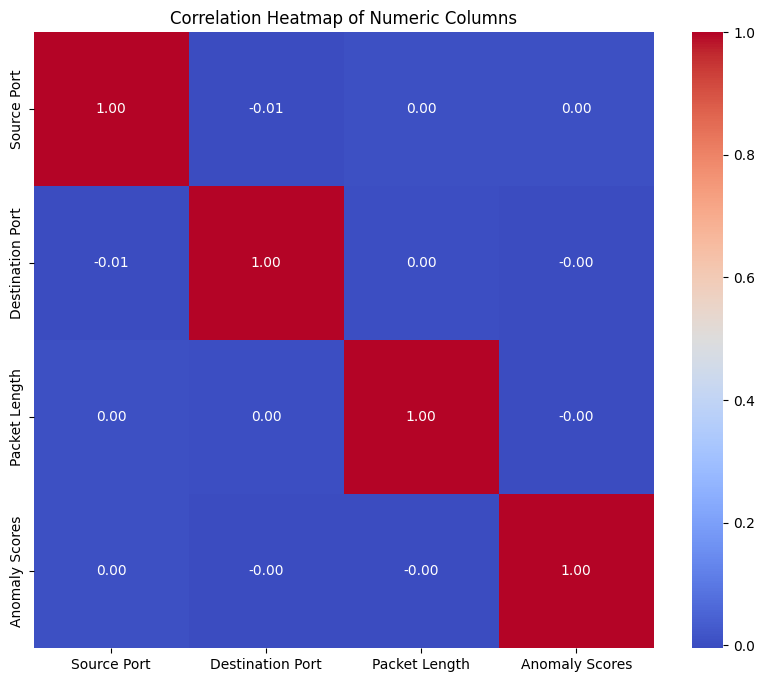

In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

numeric_df = df.select_dtypes(include='number')

corr_matrix = numeric_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Numeric Columns")
plt.show()

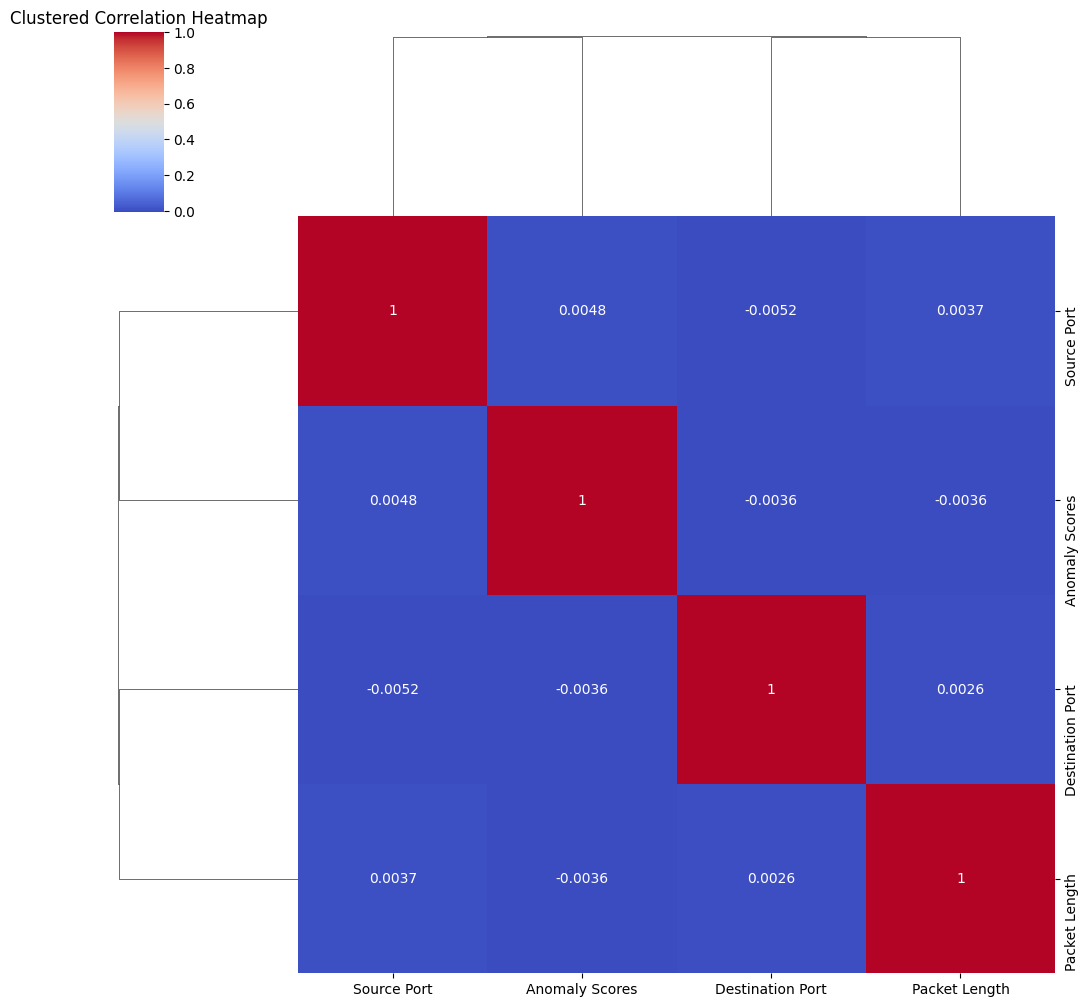

In [21]:
sns.clustermap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Clustered Correlation Heatmap")
plt.show()

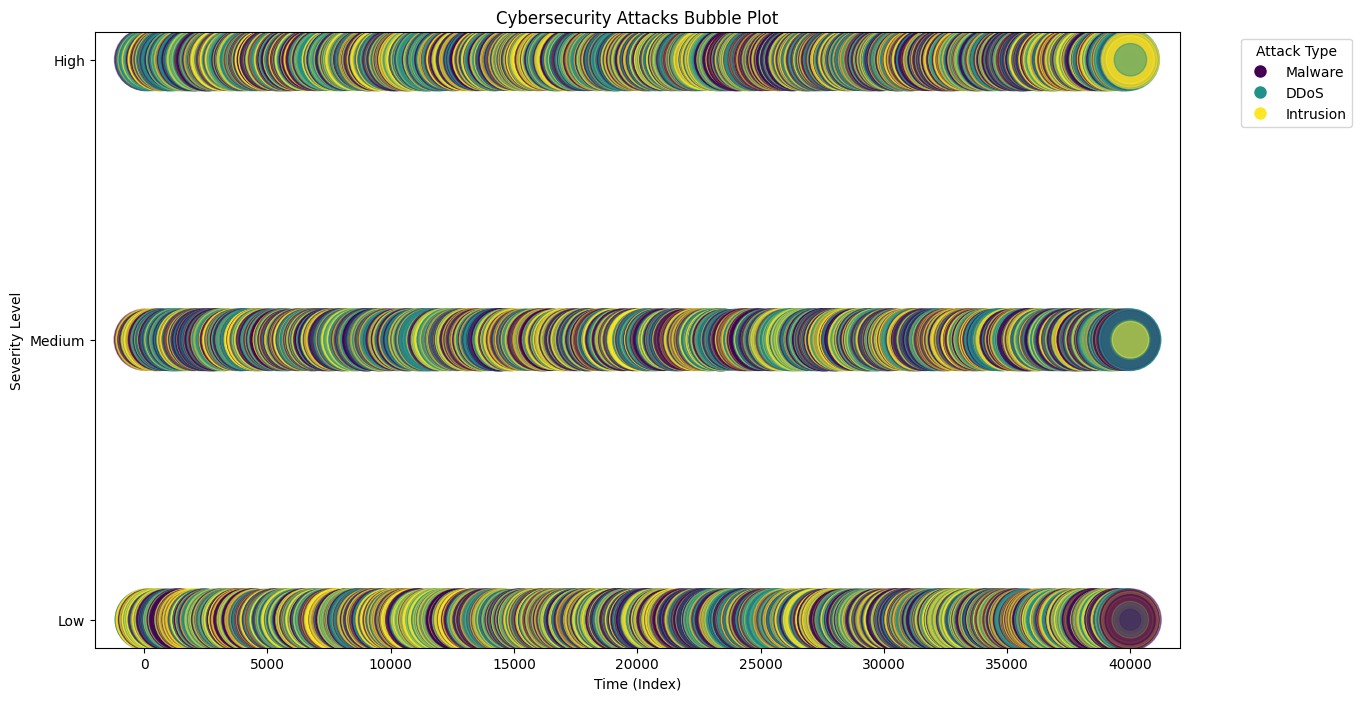

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

csv_file = "/home/codespace/.cache/kagglehub/datasets/teamincribo/cyber-security-attacks/versions/21/cybersecurity_attacks.csv"
df = pd.read_csv(csv_file)

if df['Severity Level'].dtype == 'object':
    df['Severity_num'] = pd.factorize(df['Severity Level'])[0]
else:
    df['Severity_num'] = df['Severity Level']

df['Anomaly Scores'] = pd.to_numeric(df['Anomaly Scores'], errors='coerce')

x = range(len(df))  
y = df['Severity_num']
size = df['Anomaly Scores'].fillna(0) * 20 

attack_types, attack_labels = pd.factorize(df['Attack Type'])
colors = attack_types

plt.figure(figsize=(14,8))
scatter = plt.scatter(x, y, s=size, c=colors, alpha=0.5, cmap='viridis')
plt.xlabel("Time (Index)")
plt.ylabel("Severity Level")
plt.yticks(df['Severity_num'].unique(), df['Severity Level'].unique())
plt.title("Cybersecurity Attacks Bubble Plot")

handles = [plt.Line2D([0], [0], marker='o', color='w', label=label, 
                      markerfacecolor=plt.cm.viridis(i/(len(attack_labels)-1)), markersize=10)
           for i, label in enumerate(attack_labels)]
plt.legend(handles=handles, title="Attack Type", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

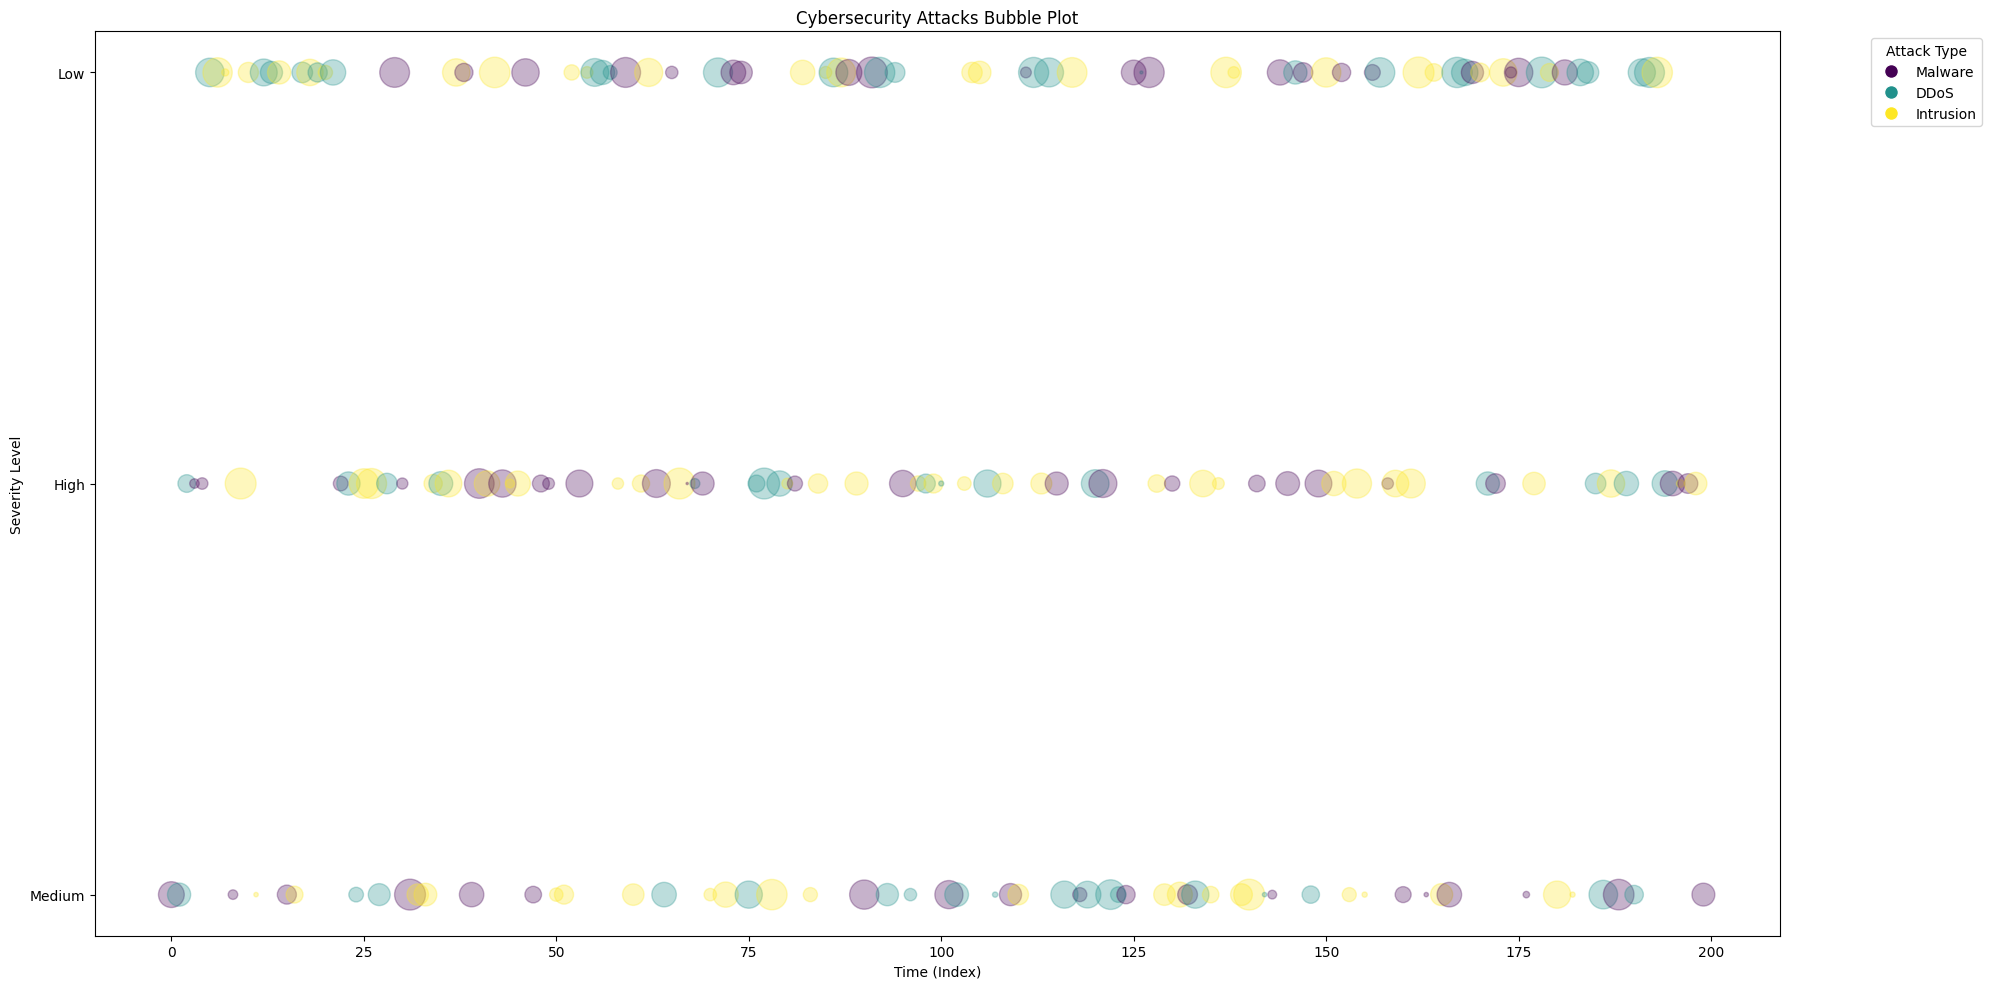

In [23]:
csv_file = "/home/codespace/.cache/kagglehub/datasets/teamincribo/cyber-security-attacks/versions/21/cybersecurity_attacks.csv"
df = pd.read_csv(csv_file)
sample_df = df.sample(n=200, random_state=42)  
if sample_df['Severity Level'].dtype == 'object':
    sample_df['Severity_num'] = pd.factorize(sample_df['Severity Level'])[0]
else:
    sample_df['Severity_num'] = sample_df['Severity Level']
sample_df['Anomaly Scores'] = pd.to_numeric(sample_df['Anomaly Scores'], errors='coerce')
x = range(len(sample_df))
y = sample_df['Severity_num']
size = sample_df['Anomaly Scores'].fillna(0) * 5 
attack_types, attack_labels = pd.factorize(sample_df['Attack Type'])
colors = attack_types
plt.figure(figsize=(18,10))
scatter = plt.scatter(x, y, s=size, c=colors, alpha=0.3, cmap='viridis')
plt.xlabel("Time (Index)")
plt.ylabel("Severity Level")
plt.yticks(sample_df['Severity_num'].unique(), sample_df['Severity Level'].unique())
plt.title("Cybersecurity Attacks Bubble Plot")
plt.tight_layout()
plt.legend(handles=handles, title="Attack Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


In [24]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

csv_file = "/home/codespace/.cache/kagglehub/datasets/teamincribo/cyber-security-attacks/versions/21/cybersecurity_attacks.csv"
df = pd.read_csv(csv_file)

numeric_df = df.select_dtypes(include=['int64', 'float64'])

scaler = StandardScaler()
scaled_data = scaler.fit_transform(numeric_df)

pca = PCA(n_components=2)  
principal_components = pca.fit_transform(scaled_data)

pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("First 5 PCA results:")
print(pca_df.head())

Explained variance ratio: [0.25233408 0.25083918]
First 5 PCA results:
        PC1       PC2
0 -0.113889 -0.497197
1  1.065070  0.380277
2  0.191222 -1.601828
3  0.896229 -0.906115
4  1.855950  0.944071


In [25]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# Load the CSV file
csv_file = "/home/codespace/.cache/kagglehub/datasets/teamincribo/cyber-security-attacks/versions/21/cybersecurity_attacks.csv"
df = pd.read_csv(csv_file)

# Drop rows with missing values in relevant columns
df = df.dropna(subset=['Anomaly Scores', 'Severity Level'])

# Feature and target selection
X = df[['Anomaly Scores']]        # Feature
y = df['Severity Level']          # Target

# If Severity Level is categorical, convert it to numeric
if y.dtype == 'object':
    y = y.astype('category').cat.codes

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit the linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# R^2 score
r2 = model.score(X_test, y_test)  # or r2_score(y_test, y_pred)
print("R^2 score:", r2)

R^2 score: -0.00040787986523960207


In [26]:
print("""An R^2 score of 0.0 means that the regression model does not explain any of the variance in the target variable PC3 using the predictors PC1 and PC2. The predicted values for PC3 from PC1 and PC2 are no better than just using the mean of PC3 for every prediction. There is no linear relationship between PC1, PC2 and PC3.""")

An R^2 score of 0.0 means that the regression model does not explain any of the variance in the target variable PC3 using the predictors PC1 and PC2. The predicted values for PC3 from PC1 and PC2 are no better than just using the mean of PC3 for every prediction. There is no linear relationship between PC1, PC2 and PC3.


In [27]:
print("""Suppose your original dataset has 100 rows and 5 numeric columns. After PCA:
pc_df will have 100 rows (one for each event) and 5 columns (PC1 to PC5).
The number in pc_df.loc[0, 'PC1'] tells you how much the first event varies along the most important direction (PC1) found by PCA.
The number in pc_df.loc[0, 'PC2'] tells you where the first event falls along the second most important direction, and so on.

Why is this useful?
Dimensionality Reduction: You can keep only the first few PCs (like PC1 and PC2) to summarize most of the variation in your data.
Visualization: You can plot PC1 vs PC2 to visualize clustering or patterns.
Feature Engineering: These scores can be used as new features for further analysis or machine learning.
""")

Suppose your original dataset has 100 rows and 5 numeric columns. After PCA:
pc_df will have 100 rows (one for each event) and 5 columns (PC1 to PC5).
The number in pc_df.loc[0, 'PC1'] tells you how much the first event varies along the most important direction (PC1) found by PCA.
The number in pc_df.loc[0, 'PC2'] tells you where the first event falls along the second most important direction, and so on.

Why is this useful?
Dimensionality Reduction: You can keep only the first few PCs (like PC1 and PC2) to summarize most of the variation in your data.
Visualization: You can plot PC1 vs PC2 to visualize clustering or patterns.
Feature Engineering: These scores can be used as new features for further analysis or machine learning.



# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 136-150 of the Storytelling With Data book as best you can. ("The power of super-categories" to the end of chapter 5). You do not have to get the exact data values right, just the overall look and feel.

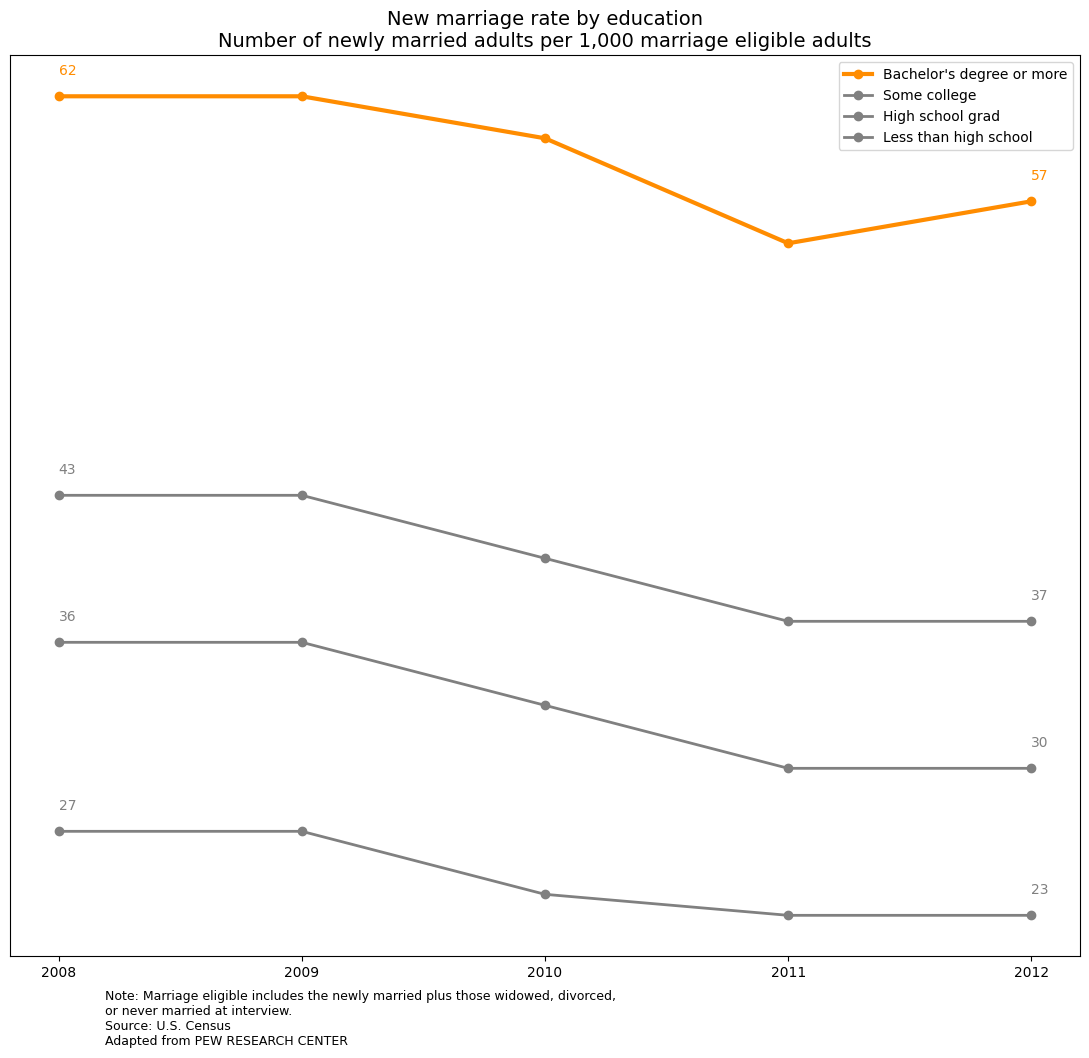

In [28]:
years = [2008, 2009, 2010, 2011, 2012]
bachelors = [62, 62, 60, 55, 57]
some_college = [43, 43, 40, 37, 37]
high_school = [36, 36, 33, 30, 30]
less_than_hs = [27, 27, 24, 23, 23]

plt.figure(figsize=(11, 10))
plt.plot(years, bachelors, label="Bachelor's degree or more", color='darkorange', linewidth=3, marker='o')
plt.plot(years, some_college, label="Some college", color='gray', linewidth=2, marker='o')
plt.plot(years, high_school, label="High school grad", color='gray', linewidth=2, marker='o')
plt.plot(years, less_than_hs, label="Less than high school", color='gray', linewidth=2, marker='o')

plt.text(2008, bachelors[0]+1, "62", color='darkorange')
plt.text(2012, bachelors[-1]+1, "57", color='darkorange')
plt.text(2008, some_college[0]+1, "43", color='gray')
plt.text(2012, some_college[-1]+1, "37", color='gray')
plt.text(2008, high_school[0]+1, "36", color='gray')
plt.text(2012, high_school[-1]+1, "30", color='gray')
plt.text(2008, less_than_hs[0]+1, "27", color='gray')
plt.text(2012, less_than_hs[-1]+1, "23", color='gray')

plt.title("New marriage rate by education\nNumber of newly married adults per 1,000 marriage eligible adults", fontsize=14)
plt.xlabel("")
plt.ylabel("")

plt.xticks(years)
plt.yticks([])
plt.grid(False)

plt.legend(loc='upper right')

plt.figtext(0.1, -0.05, "Note: Marriage eligible includes the newly married plus those widowed, divorced,\n"
                        "or never married at interview.\n"
                        "Source: U.S. Census\n"
                        "Adapted from PEW RESEARCH CENTER", ha="left", fontsize=9)

plt.tight_layout()
plt.show()